# CNN con Audio 🎤

Dataset: **TESS (Toronto Emotional Speech Set)**, una colección de frases cortas grabadas por dos actrices expresando 7 emociones diferentes:
`angry`, `disgust`, `fear`, `happy`, `neutral`, `pleasant_surprise` y `sad`.

Estrategia:

```
Audio .wav  ──►  Mel-Spectrogram (dB)  ──►  CNN  ──►  Predicción de emoción
```

---
## 1. Configuración Inicial

In [17]:
%pip install lightning

In [18]:
import os
import random
import glob
import pathlib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import torchaudio
import torchaudio.transforms as T

import pytorch_lightning as pl

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from IPython.display import Audio, display
from collections import Counter

# ── Reproducibilidad ──────────────────────────────────────────────────────────
pl.seed_everything(42)

# ── Estética de gráficas ──────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams['figure.dpi'] = 100

print("✅ Librerías cargadas correctamente.")
print(f"   PyTorch     : {torch.__version__}")
print(f"   Torchaudio  : {torchaudio.__version__}")
print(f"   Lightning   : {pl.__version__}")

INFO:lightning_fabric.utilities.seed:Seed set to 42


✅ Librerías cargadas correctamente.
   PyTorch     : 2.10.0+cu128
   Torchaudio  : 2.10.0+cu128
   Lightning   : 2.6.1


---
## 2. Importar datos

Usamos **KaggleHub** para descargar automáticamente el dataset TESS:
- Cada carpeta tiene la estructura como `OAF_angry` ó `YAF_happy`.
- El sufijo del nombre de la carpeta es la **etiqueta de emoción**.
- Dentro hay archivos `.wav` (una grabación por cada frase).

Después graficamos cuántos archivos hay por clase para ver si el dataset está balanceado.

In [19]:
import kagglehub

# Descarga el dataset (usa caché si ya lo tienes)
DATASET_PATH = kagglehub.dataset_download("ejlok1/toronto-emotional-speech-set-tess")
print(f"📂 Ruta del dataset: {DATASET_PATH}")

Using Colab cache for faster access to the 'toronto-emotional-speech-set-tess' dataset.
📂 Ruta del dataset: /kaggle/input/toronto-emotional-speech-set-tess


In [20]:
# ── Escanear carpetas y construir lista (ruta, etiqueta) ──────────────────────
all_files   = []   # lista de rutas a archivos .wav
all_labels  = []   # lista de etiquetas (strings) correspondientes

for folder in sorted(pathlib.Path(DATASET_PATH).rglob("*")):
    if folder.is_dir():
        # La convención es: OAF_<emoción> o YAF_<emoción>
        parts = folder.name.lower().split("_")
        if len(parts) >= 2:
            emotion = "_".join(parts[1:])  # maneja 'pleasant_surprise'
            wavs = list(folder.glob("*.wav"))
            for w in wavs:
                all_files.append(str(w))
                all_labels.append(emotion)

# ── Mapeo etiqueta ↔ índice numérico ─────────────────────────────────────────
CLASSES    = sorted(set(all_labels))
NUM_CLASSES = len(CLASSES)
label2idx  = {c: i for i, c in enumerate(CLASSES)}
idx2label  = {i: c for c, i in label2idx.items()}

print(f"📊 Total de archivos encontrados : {len(all_files)}")
print(f"🎭 Emociones ({NUM_CLASSES} clases)     : {CLASSES}")

📊 Total de archivos encontrados : 5600
🎭 Emociones (8 clases)     : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'pleasant_surprise', 'pleasant_surprised', 'sad']


In [21]:
# ── Normalizar etiquetas: Unificar 'pleasant_surprised' -> 'pleasant_surprise' ──
all_labels = [l if l != 'pleasant_surprised' else 'pleasant_surprise' for l in all_labels]

# ── Re-generar mapeo de clases ───────────────────────────────────────────────
CLASSES     = sorted(set(all_labels))
NUM_CLASSES = len(CLASSES)
label2idx   = {c: i for i, c in enumerate(CLASSES)}
idx2label   = {i: c for c, i in label2idx.items()}

print(f"✅ Etiquetas unificadas.")
print(f"📊 Total de archivos: {len(all_files)}")
print(f"🎭 Nuevas clases ({NUM_CLASSES}): {CLASSES}")

✅ Etiquetas unificadas.
📊 Total de archivos: 5600
🎭 Nuevas clases (7): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'pleasant_surprise', 'sad']


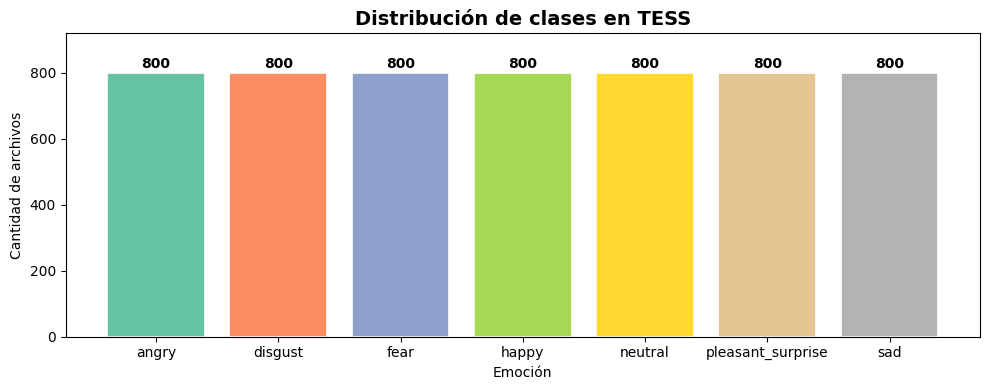


✅ Dataset perfectamente balanceado: misma cantidad de archivos por clase.


In [22]:
# ── Gráfica de distribución de clases ────────────────────────────────────────
counts = Counter(all_labels)
clases_ord = sorted(counts.keys())
vals       = [counts[c] for c in clases_ord]

colors = plt.cm.Set2(np.linspace(0, 1, len(clases_ord)))

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(clases_ord, vals, color=colors, edgecolor='white', linewidth=1.2)
ax.set_title("Distribución de clases en TESS", fontsize=14, fontweight='bold')
ax.set_xlabel("Emoción")
ax.set_ylabel("Cantidad de archivos")
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, max(vals) * 1.15)
plt.tight_layout()
plt.show()

print("\n✅ Dataset perfectamente balanceado: misma cantidad de archivos por clase.")

---
## 3. Visualización de los Datos

In [23]:
# ── Reproducir un ejemplo por emoción ────────────────────────────────────────
print("🎧 Un ejemplo de audio por emoción:\n")
for emotion in CLASSES:
    # Elegir un archivo aleatorio de esa emoción
    candidates = [f for f, l in zip(all_files, all_labels) if l == emotion]
    sample_path = random.choice(candidates)
    waveform, sr = torchaudio.load(sample_path)
    print(f"  🎭 {emotion.upper():20s}  |  {sr} Hz  |  {waveform.shape[1]/sr:.2f}s")
    display(Audio(waveform.numpy()[0], rate=sr))

🎧 Un ejemplo de audio por emoción:

  🎭 ANGRY                 |  24414 Hz  |  2.18s


  🎭 DISGUST               |  24414 Hz  |  2.44s


  🎭 FEAR                  |  24414 Hz  |  1.63s


  🎭 HAPPY                 |  24414 Hz  |  1.76s


  🎭 NEUTRAL               |  24414 Hz  |  2.29s


  🎭 PLEASANT_SURPRISE     |  24414 Hz  |  1.72s


  🎭 SAD                   |  24414 Hz  |  2.22s


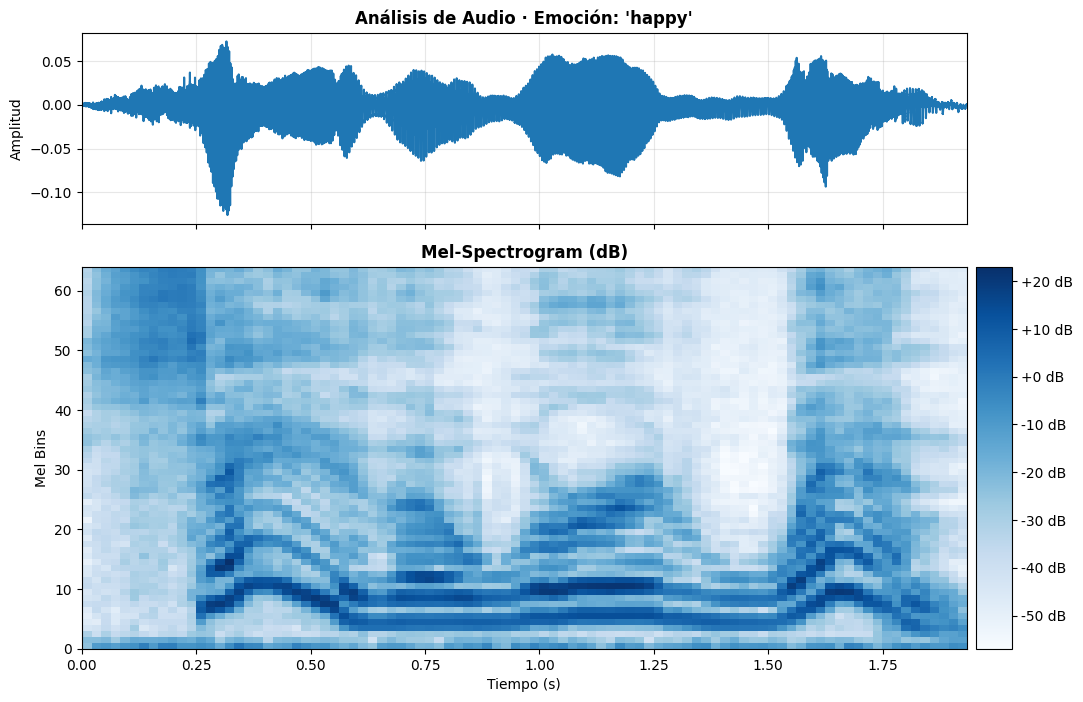


✅ Alineación corregida usando un eje dedicado para la colorbar.
✅ El Mel-Spectrogram tiene 64 filas y 93 frames.


In [24]:
import matplotlib.gridspec as gridspec

# ── Visualizar forma de onda + Mel-Spectrogram de una muestra ─────────────────
sample_path = random.choice(all_files)
sample_label = all_labels[all_files.index(sample_path)]

waveform, sr = torchaudio.load(sample_path)
# Forzar mono si es estéreo
if waveform.shape[0] > 1:
    waveform = waveform.mean(dim=0, keepdim=True)

display(Audio(waveform.numpy()[0], rate=sr))

# Pipeline de preprocesamiento
mel_transform = T.MelSpectrogram(
    sample_rate=sr,
    n_fft=1024,
    hop_length=512,
    n_mels=64
)
to_db = T.AmplitudeToDB(stype='power', top_db=80.0)

mel_spec = mel_transform(waveform)      # [1, 64, T]
mel_db   = to_db(mel_spec)              # [1, 64, T]

tiempo = torch.arange(waveform.shape[1]) / sr

# ── Configuración de la figura con GridSpec para alineación perfecta ──────────
fig = plt.figure(figsize=(12, 8))
# Creamos 2 columnas: la primera para los plots, la segunda (muy estrecha) para la colorbar
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 2], width_ratios=[25, 1], hspace=0.15, wspace=0.02)

ax_wave = fig.add_subplot(gs[0, 0])
ax_mel = fig.add_subplot(gs[1, 0], sharex=ax_wave)
ax_cb = fig.add_subplot(gs[1, 1]) # Eje dedicado para la colorbar

# Forma de onda
ax_wave.plot(tiempo.numpy(), waveform[0].numpy(), color='#1f77b4')
ax_wave.set_title(f"Análisis de Audio · Emoción: '{sample_label}'", fontweight='bold')
ax_wave.set_ylabel("Amplitud")
ax_wave.grid(True, alpha=0.3)
plt.setp(ax_wave.get_xticklabels(), visible=False) # Ocultar labels superiores para limpieza

# Mel-Spectrogram
extent = [tiempo[0], tiempo[-1], 0, 64]
im = ax_mel.imshow(
    mel_db[0].numpy(), origin='lower', aspect='auto',
    cmap='Blues', extent=extent
)
ax_mel.set_title(f"Mel-Spectrogram (dB)", fontweight='bold')
ax_mel.set_xlabel("Tiempo (s)")
ax_mel.set_ylabel("Mel Bins")

# Dibujar la colorbar en el eje dedicado
plt.colorbar(im, cax=ax_cb, format='%+2.0f dB')

plt.show()

print(f"\n✅ Alineación corregida usando un eje dedicado para la colorbar.")
print(f"✅ El Mel-Spectrogram tiene {mel_db.shape[1]} filas y {mel_db.shape[2]} frames.")

---
## 4. `AudioDataset`

PyTorch trabaja con `Dataset`, que es simplemente una clase que sabe:

1. **Cuántos ejemplos hay** (`__len__`)
2. **Cómo cargar el ejemplo `i`-ésimo** (`__getitem__`)

Nuestra clase `AudioDataset` carga cada archivo `.wav`, aplica el pipeline completo de preprocesamiento
(Mel-Spectrogram → dB) y retorna una tupla `(tensor_imagen, etiqueta_numérica)`.

### El problema del tamaño variable ⚠️
Los archivos de audio tienen longitudes ligeramente distintas. Para que PyTorch pueda agruparlos en *batches* de forma automática, **todos los tensores del batch deben tener el mismo tamaño**.

La solución más simple es fijar un **número máximo de frames** (`TARGET_LENGTH = 128`) y:
- Si el espectrograma es **más largo** → lo recortamos.
- Si es **más corto** → lo rellenamos con ceros (padding).

In [25]:
# ── Parámetros del preprocesamiento ──────────────────────────────────────────
SAMPLE_RATE   = 24414   # TESS usa esta frecuencia de muestreo
N_MELS        = 64
N_FFT         = 1024
HOP_LENGTH    = 512
TARGET_LENGTH = 128     # Frames de tiempo que queremos en el espectrograma


class AudioDataset(Dataset):
    """Dataset personalizado para TESS.

    Carga archivos .wav, los convierte a Mel-Spectrogram (dB)
    y normaliza la longitud a TARGET_LENGTH frames.
    """

    def __init__(self, file_paths, labels, label2idx,
                 sample_rate=SAMPLE_RATE, n_mels=N_MELS,
                 n_fft=N_FFT, hop_length=HOP_LENGTH,
                 target_length=TARGET_LENGTH):

        self.file_paths    = file_paths
        self.labels        = labels
        self.label2idx     = label2idx
        self.target_length = target_length
        self.sample_rate   = sample_rate

        # Pipeline de transformación (solo se instancia una vez, se reutiliza)
        self.mel_transform = T.MelSpectrogram(
            sample_rate=sample_rate,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels
        )
        self.to_db = T.AmplitudeToDB(stype='power', top_db=80.0)

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        path  = self.file_paths[idx]
        label = self.label2idx[self.labels[idx]]

        # 1. Cargar audio
        waveform, sr = torchaudio.load(path)

        # 2. Normalizar a mono (1 canal)
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        # 3. Re-muestrear si es necesario
        if sr != self.sample_rate:
            resampler = T.Resample(orig_freq=sr, new_freq=self.sample_rate)
            waveform  = resampler(waveform)

        # 4. Calcular Mel-Spectrogram y convertir a dB
        mel = self.mel_transform(waveform)  # [1, n_mels, T]
        mel = self.to_db(mel)               # [1, n_mels, T]

        # 5. Ajustar longitud temporal a TARGET_LENGTH
        T_actual = mel.shape[2]
        if T_actual > self.target_length:
            # Recortar del centro para conservar la parte más informativa
            start = (T_actual - self.target_length) // 2
            mel   = mel[:, :, start : start + self.target_length]
        elif T_actual < self.target_length:
            # Rellenar con ceros al final
            pad_size = self.target_length - T_actual
            mel = F.pad(mel, (0, pad_size))  # padding solo en la dimensión temporal

        return mel, label


# ── Pequeña prueba de que el Dataset funciona ─────────────────────────────────
full_dataset = AudioDataset(all_files, all_labels, label2idx)

sample_tensor, sample_label_idx = full_dataset[0]

print(f"✅ AudioDataset creado con {len(full_dataset)} ejemplos.")
print(f"\n🔎 Primer ejemplo:")
print(f"   Shape del tensor  : {sample_tensor.shape}")
print(f"   Tipo              : {sample_tensor.dtype}")
print(f"   Valor mínimo (dB) : {sample_tensor.min():.2f}")
print(f"   Valor máximo (dB) : {sample_tensor.max():.2f}")
print(f"   Etiqueta numérica : {sample_label_idx}  →  '{idx2label[sample_label_idx]}'")
print()
print("📐 Interpretación del shape [1, 64, 128]:")
print("   1   → 1 canal (imagen en escala de grises, como las fotos en blanco y negro)")
print("   64  → 64 filtros Mel (alto de la imagen = resolución de frecuencia)")
print("   128 → 128 frames de tiempo (ancho de la imagen = resolución temporal)")

✅ AudioDataset creado con 5600 ejemplos.

🔎 Primer ejemplo:
   Shape del tensor  : torch.Size([1, 64, 128])
   Tipo              : torch.float32
   Valor mínimo (dB) : -52.63
   Valor máximo (dB) : 27.37
   Etiqueta numérica : 2  →  'fear'

📐 Interpretación del shape [1, 64, 128]:
   1   → 1 canal (imagen en escala de grises, como las fotos en blanco y negro)
   64  → 64 filtros Mel (alto de la imagen = resolución de frecuencia)
   128 → 128 frames de tiempo (ancho de la imagen = resolución temporal)


---
## 5. DataLoaders

Dividimos aleatoriamente el dataset en:
- **Entrenamiento (80%):** La red verá estos ejemplos durante el entrenamiento.
- **Validación (20%):** Ejemplos que la red **nunca vio** mientras aprendía. Los usamos para medir qué tan bien generaliza.

El `DataLoader` es el "mesero" que sirve los datos en *batches* (lotes). Nosotros definimos:
- `batch_size`: Cuántos ejemplos procesar a la vez.
- `shuffle=True` en entrenamiento: Para que no vea siempre los datos en el mismo orden.

In [26]:
BATCH_SIZE = 32
TRAIN_FRAC = 0.80

# División 80 / 20
n_total = len(full_dataset)
n_train = int(TRAIN_FRAC * n_total)
n_val   = n_total - n_train

train_dataset, val_dataset = random_split(
    full_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42)   # reproducible
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4
)
val_loader = DataLoader(
    val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4
)

print("✅ DataLoaders listos.")
print(f"   Entrenamiento : {len(train_dataset):,} ejemplos  ({len(train_loader)} batches de {BATCH_SIZE})")
print(f"   Validación    : {len(val_dataset):,} ejemplos  ({len(val_loader)} batches)")

# Verificar dimensiones de un batch real
batch_imgs, batch_labels = next(iter(train_loader))
print(f"\n🔎 Dimensiones de un batch:")
print(f"   Imágenes : {batch_imgs.shape}   ← [batch_size, canales, mel_bins, frames]")
print(f"   Etiquetas: {batch_labels.shape}  ← [batch_size]")

✅ DataLoaders listos.
   Entrenamiento : 4,480 ejemplos  (140 batches de 32)
   Validación    : 1,120 ejemplos  (35 batches)

🔎 Dimensiones de un batch:
   Imágenes : torch.Size([32, 1, 64, 128])   ← [batch_size, canales, mel_bins, frames]
   Etiquetas: torch.Size([32])  ← [batch_size]


---
## 6. `EmotionCNN`

Construimos nuestra red neuronal usando `pl.LightningModule`. Tiene dos grandes bloques:

### A) Extractor de Características (Convoluciones)
Tres bloques, cada uno formado por:
- **Conv2d:** Aprende filtros que detectan patrones en el Mel-Spectrogram (armónicos, silencios, ataques).
- **BatchNorm2d:** Normaliza las activaciones para estabilizar el entrenamiento (acelera la convergencia).
- **ReLU:** Introduce no-linealidad (sin esto, todo sería una gran multiplicación de matrices).
- **MaxPool2d(2,2):** Resume la imagen a la mitad. Esto hace la red más rápida y da invarianza a pequeños desplazamientos.

### B) Clasificador (Capas Lineales)
Al final aplanamos el cubo de activaciones y lo pasamos por dos capas lineales. La ultima tiene **7 salidas** (una por emoción).

### ¿Cómo calcular el tamaño del Flatten?
Partimos de `[1, 64, 128]` y aplicamos 3 veces MaxPool(2,2):
```
Entrada:      C=1,  H=64, W=128
Tras Pool 1:  C=32, H=32, W=64
Tras Pool 2:  C=64, H=16, W=32
Tras Pool 3:  C=128,H= 8, W=16
Flatten:      128 × 8 × 16 = 16 384 valores
```

In [27]:
class EmotionCNN(pl.LightningModule):
    """Versión simplificada de la CNN para evitar el sobreajuste perfecto.

    Entrada: Mel-Spectrogram de forma [batch, 1, 64, 128].
    """

    def __init__(self, n_classes=7, lr=1e-3):
        super().__init__()
        self.lr = lr
        self.save_hyperparameters()

        # ── Bloque 1: Son 4 filtros ──
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=4, kernel_size=3, padding=1),
            nn.BatchNorm2d(4),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  # 64x128 → 32x64
        )

        # ── Bloque 2: Son 8 filtros ──
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=4, out_channels=8, kernel_size=3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  # 32x64 → 16x32
        )

        # ── Clasificador Minimalista ──
        # Tras 2 pools: 8 canales x 16 alto x 32 ancho = 4,096 valores
        self.flatten = nn.Flatten()
        self.fc1     = nn.Linear(8 * 16 * 32, 64)
        self.dropout = nn.Dropout(p=0.5)
        self.fc2     = nn.Linear(64, n_classes)

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc = (torch.argmax(logits, dim=1) == y).float().mean()
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        self.log('train_acc', acc, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc = (torch.argmax(logits, dim=1) == y).float().mean()
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)
        return {'optimizer': optimizer, 'lr_scheduler': {'scheduler': scheduler, 'monitor': 'val_loss'}}

# Re-instanciar modelo
model = EmotionCNN(n_classes=NUM_CLASSES)
total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Modelo creado con {total_params:,} parámetros.")

✅ Modelo creado con 263,023 parámetros.


---
## 7. A Entrenar!

El `Trainer` de PyTorch Lightning orquesta todo el proceso de entrenamiento sin que tengamos que escribir los loops manualmente:

- `max_epochs` : Cuántas veces verá el modelo **todos** los ejemplos de entrenamiento.
- `accelerator='auto'`: Usará GPU si está disponible, si no, CPU.

In [28]:
MAX_EPOCHS = 5

trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='auto',
    log_every_n_steps=10,
    enable_progress_bar=True,
)

# ¡El entrenamiento ocurre aquí!
trainer.fit(model, train_loader, val_loader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name        ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ conv_block1 │ Sequential │     48 │ train │     0 │
│ 1 │ conv_block2 │ Sequential │    312 │ train │     0 │
│ 2 │ flatten     │ Flatten    │      0 │ train │     0 │
│ 3 │ fc1         │ Linear     │  262 K │ train │     0 │
│ 4 │ dropout     │ Dropout    │      0 │ train │     0 │
│ 5 │ fc2         │ Linear     │    455 │ train │     0 │
└───┴─────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 263 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 263 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


✅ Cargando métricas desde: lightning_logs/version_4


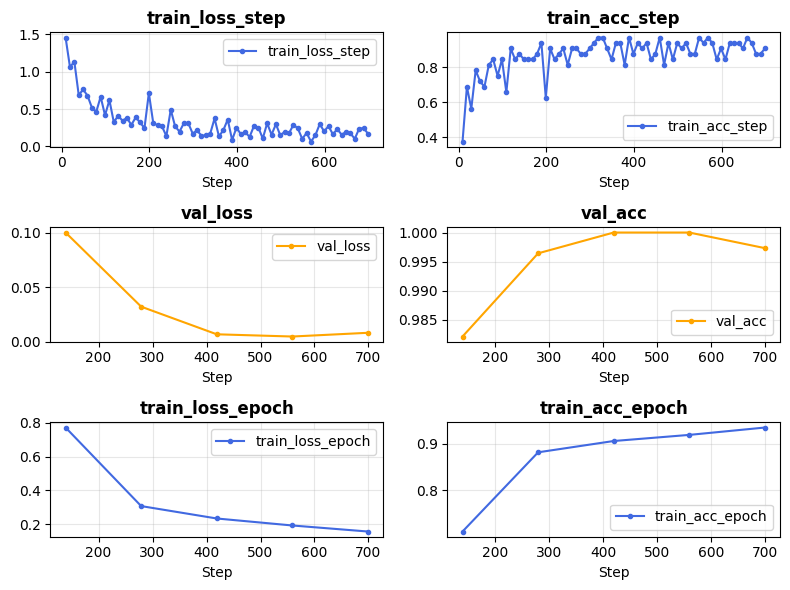

In [29]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import matplotlib.pyplot as plt
import math
import pathlib

# ── Encontrar la versión más reciente de los logs ─────────────────────
log_dirs = sorted(pathlib.Path('lightning_logs').glob('version_*'), key=lambda x: int(x.name.split('_')[1]))
if not log_dirs:
    print("❌ No se encontraron logs de entrenamiento.")
else:
    latest_path = str(log_dirs[-1])
    print(f"✅ Cargando métricas desde: {latest_path}")

    event_acc = EventAccumulator(latest_path)
    event_acc.Reload()

    # Filtrar métricas que empiecen con 'train' o 'val'
    all_scalars = event_acc.Tags()['scalars']
    target_metrics = [m for m in all_scalars if m.startswith(('train', 'val'))]

    # Configurar la cuadrícula de dos columnas
    n_plots = min(len(target_metrics), 6)
    cols = 2
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(8, rows * 2))
    axes = axes.flatten()

    for i, metric_name in enumerate(target_metrics[:6]):
        data = event_acc.Scalars(metric_name)
        steps = [s.step for s in data]
        values = [s.value for s in data]

        color = 'royalblue' if 'train' in metric_name else 'orange'
        axes[i].plot(steps, values, label=metric_name, color=color, marker='.')
        axes[i].set_title(metric_name, fontweight='bold')
        axes[i].set_xlabel('Step')
        axes[i].grid(True, alpha=0.3)
        axes[i].legend()

    # Ocultar ejes vacíos si hay menos de 6 métricas
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

---
## 8. Resultados

Tomamos **10 espectrogramas del set de validación** (que el modelo nunca vio durante el entrenamiento) y le pedimos que prediga la emoción.

- El título en **verde** indica que el modelo acertó ✅
- El título en **rojo** indica que el modelo se equivocó ❌

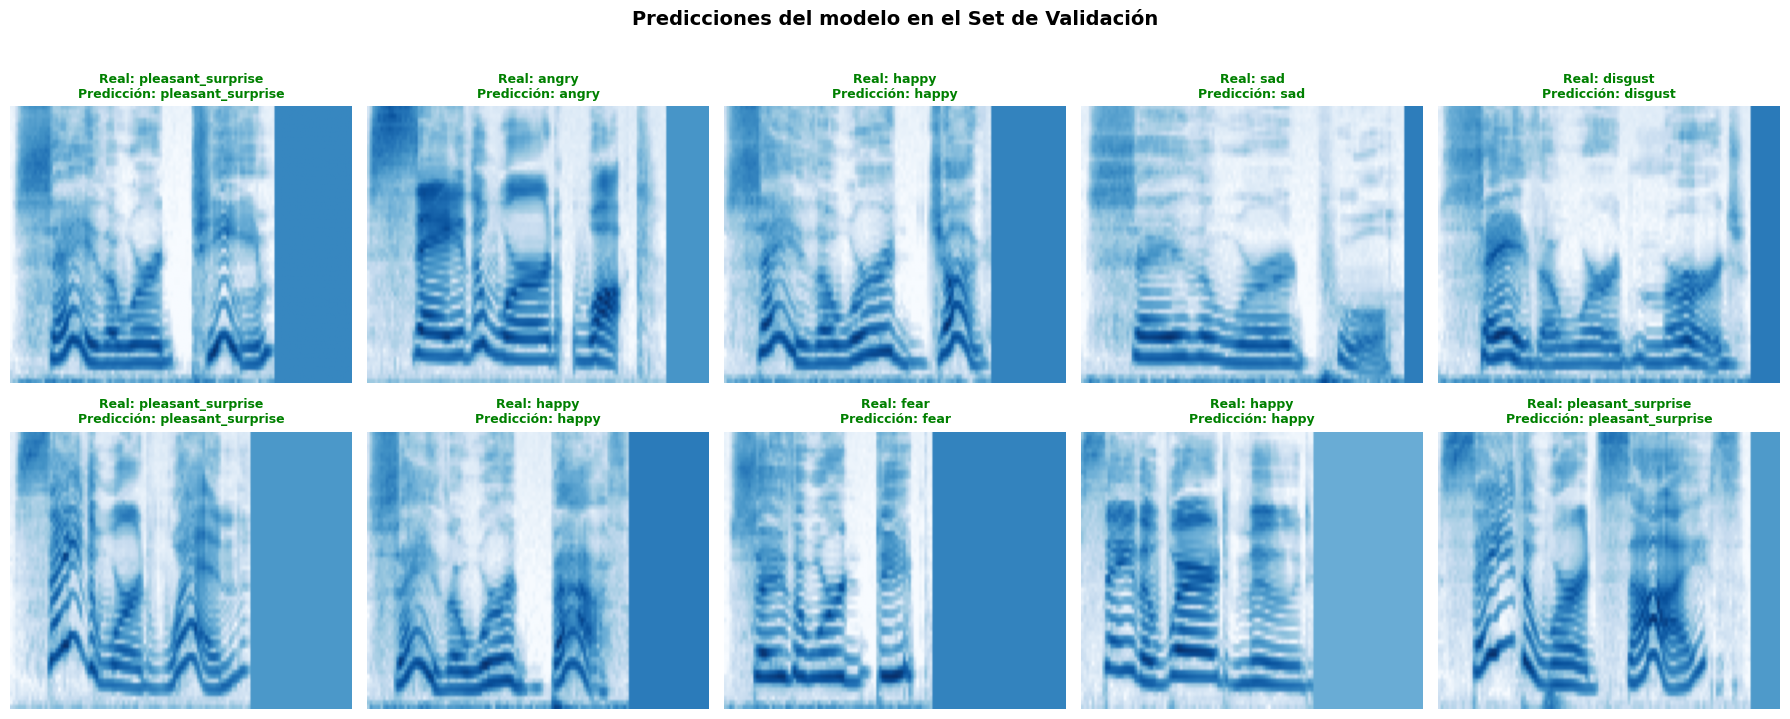

In [30]:
model.eval()

# ── Tomar 10 muestras del set de validación ───────────────────────────────────
# Pedimos un batch al val_loader y usamos los primeros 10 elementos
val_imgs, val_labels_batch = next(iter(val_loader))

with torch.no_grad():
    logits = model(val_imgs[:10])
    preds  = torch.argmax(logits, dim=1)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for i, ax in enumerate(axes.flat):
    spec = val_imgs[i, 0].numpy()         # [64, 128] → imagen 2D
    ax.imshow(spec, origin='lower', aspect='auto', cmap='Blues')

    real      = idx2label[val_labels_batch[i].item()]
    predicted = idx2label[preds[i].item()]
    color     = 'green' if real == predicted else 'red'

    ax.set_title(
        f"Real: {real}\nPredicción: {predicted}",
        color=color, fontweight='bold', fontsize=9
    )
    ax.axis('off')

plt.suptitle("Predicciones del modelo en el Set de Validación",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

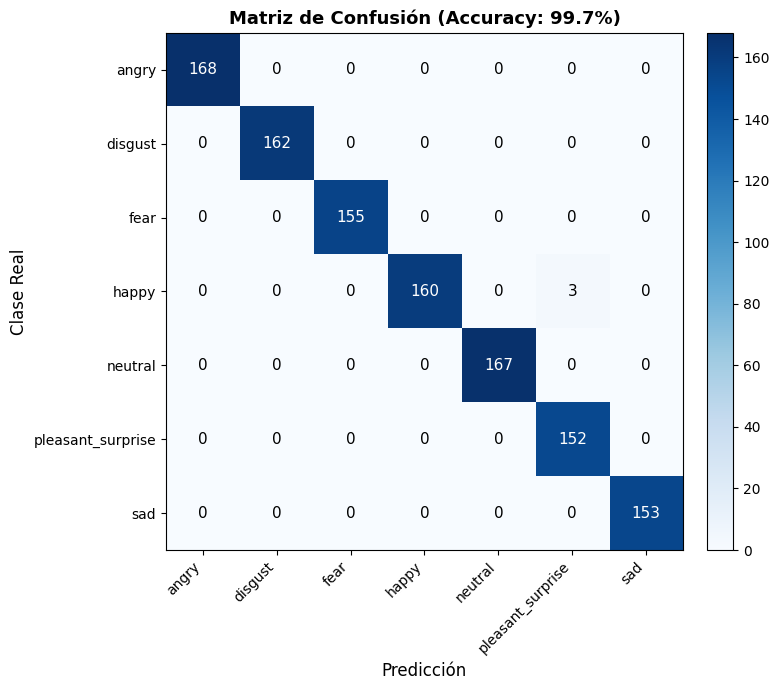


 Reporte de Clasificación:
                   precision    recall  f1-score   support

            angry       1.00      1.00      1.00       168
          disgust       1.00      1.00      1.00       162
             fear       1.00      1.00      1.00       155
            happy       1.00      0.98      0.99       163
          neutral       1.00      1.00      1.00       167
pleasant_surprise       0.98      1.00      0.99       152
              sad       1.00      1.00      1.00       153

         accuracy                           1.00      1120
        macro avg       1.00      1.00      1.00      1120
     weighted avg       1.00      1.00      1.00      1120



In [32]:
from sklearn.metrics import classification_report

# ── Matriz de confusión sobre TODO el set de validación ───────────────────────
all_preds  = []
all_true   = []

model.eval()
with torch.no_grad():
    for imgs, labels in val_loader:
        logits = model(imgs)
        preds  = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())

# Construir matriz de confusión manualmente
confusion = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
for t, p in zip(all_true, all_preds):
    confusion[t, p] += 1

overall_acc = np.trace(confusion) / np.sum(confusion) * 100

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(confusion, cmap='Blues')

ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASSES, rotation=45, ha='right')
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASSES)
ax.set_xlabel("Predicción", fontsize=12)
ax.set_ylabel("Clase Real",  fontsize=12)
ax.set_title(f"Matriz de Confusión (Accuracy: {overall_acc:.1f}%)",
             fontsize=13, fontweight='bold')

thresh = confusion.max() / 2
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, confusion[i, j],
                ha='center', va='center', fontsize=11,
                color='white' if confusion[i, j] > thresh else 'black')

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# ── Reporte de Clasificación Detallado ───────────────────────────────────
print("\n Reporte de Clasificación:")
print(classification_report(all_true, all_preds, target_names=CLASSES))